In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle

In [ ]:
path_mc = "chunks_MC"
path_data = "chunks/"
signal_path = "/home/aegis/ether/Research_HEP/NRAD/Signal/processed_signal"
# scaler_path = "/ether/aegis/Research_HEP/NRAD/SemiVisJets/mc_scalers"

var_names = ["ht", "met", "m_jj", "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2"]

# with open(f"{scaler_path}/mc_scaler_chunk03.pkl","rb") as f:
#     mc_scaler = pickle.load(f)

Data_chunk_num = 6
MC_chunk_num = 3

# Choose MC2 and Data 01
MC_chunk = f"{path_mc}/mc_chunk_{MC_chunk_num:02d}.npz"
data_chunk = f"{path_data}/data_chunk_{Data_chunk_num:02d}.npz"


mc_events = np.load(MC_chunk, allow_pickle=True)

X_mc = np.column_stack([mc_events[key] for key in var_names + ["sample"]])
# mc_events = mc_scaler.transform(X_mc)
mc_events = X_mc
mc_events = {
    key: mc_events[:, i] for i, key in enumerate(var_names)
}


data_events = np.load(data_chunk, allow_pickle=True)
X_data = np.column_stack([data_events[key] for key in var_names])
# data_events = mc_scaler.transform(X_data)
data_events = X_data
data_events = {
    key: data_events[:, i] for i, key in enumerate(var_names)
}


VARIABLES = {
    "m_jj": (0, 9000, 20, r"$m_{jj}$ [GeV]", True),
    "tau21_j1": (0, 1.5, 20, r"$\tau_{21}^{j1}$", False),
    "tau21_j2": (0, 1.5, 20, r"$\tau_{21}^{j2}$", False),
    "tau32_j1": (0, 1.5, 20, r"$\tau_{32}^{j1}$", False),
    "tau32_j2": (0, 1.5, 20, r"$\tau_{32}^{j2}$", False),
    "met": (0, 2000, 20, r"$E_{T}^{miss}$ [GeV]", True),
    "ht": (0, 5000, 20, r"$H_{T}$ [GeV]", True),
}



['__abstractmethods__', '__class__', '__class_getitem__', '__contains__', '__del__', '__delattr__', '__dict__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_files', 'allow_pickle', 'close', 'f', 'fid', 'files', 'get', 'items', 'keys', 'max_header_size', 'pickle_kwargs', 'values', 'zip']
KeysView(<numpy.lib.npyio.NpzFile object at 0x762b04367ee0>)


In [12]:
# Load Signal

signal_samples = {}
signal_modes = ["1000_2", "1000_4", "1000_6", "1000_8", "2000_2", "2000_4", "2000_6", "2000_8", "3000_2", "3000_4", "3000_6", "3000_8"]

# Import signal samples
all_columns = [
    "pT_j1", "eta_j1", "phi_j1",
    "pT_j2", "eta_j2", "phi_j2",
    "m_jj", "tau21_j1", "tau21_j2",
    "tau32_j1", "tau32_j2",
    "met", "phi_met", "min_dPhi", "ht"
]

# Find indices of desired variables
cols_to_use = [all_columns.index(v) for v in var_names]

for mode in signal_modes:
    signal_data = np.loadtxt(f"{signal_path}/{mode}_events.txt", skiprows=1, usecols=cols_to_use)

    # signal_samples[mode] = mc_scaler.transform(signal_data)
    signal_samples[mode] = signal_data
    print(f"Loaded signal mode {mode} with shape: {signal_data.shape}")

Loaded signal mode 1000_2 with shape: (991, 7)
Loaded signal mode 1000_4 with shape: (963, 7)
Loaded signal mode 1000_6 with shape: (914, 7)
Loaded signal mode 1000_8 with shape: (960, 7)
Loaded signal mode 2000_2 with shape: (4129, 7)
Loaded signal mode 2000_4 with shape: (4339, 7)
Loaded signal mode 2000_6 with shape: (4387, 7)
Loaded signal mode 2000_8 with shape: (4469, 7)
Loaded signal mode 3000_2 with shape: (2958, 7)
Loaded signal mode 3000_4 with shape: (3070, 7)
Loaded signal mode 3000_6 with shape: (3087, 7)
Loaded signal mode 3000_8 with shape: (3252, 7)


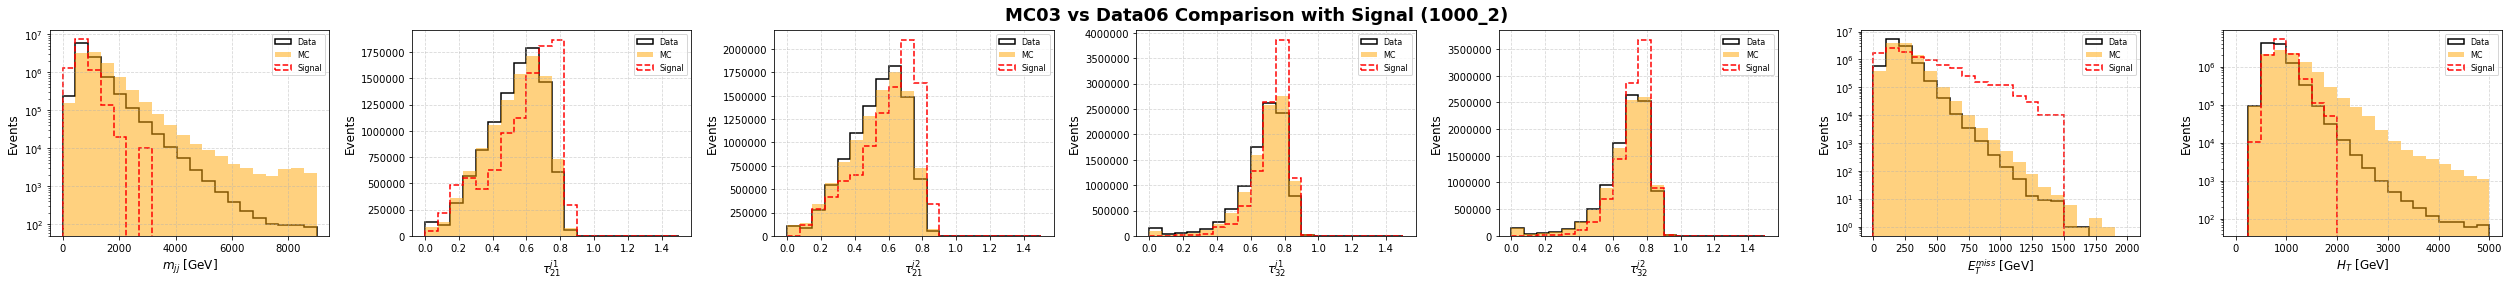

In [13]:
# Plot configuration
n_cols = 3
n_rows = int(np.ceil(len(VARIABLES) / n_cols))
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
# axes = axes.flatten()

# Style settings for a cleaner look
# plt.style.use("seaborn-v0_8-muted")
plt.rcParams.update({
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})
mode = "1000_2"
signal_to_plot = signal_samples[mode]
# Create a single row of subplots
n_vars = len(VARIABLES)
fig, axes = plt.subplots(1, n_vars, figsize=(5 * n_vars, 4), squeeze=False)
axes = axes[0]  # unpack the single row

for i, (var, (xmin, xmax, nbins, xlabel, logy)) in enumerate(VARIABLES.items()):
    ax = axes[i]
    
    if var not in mc_events or var not in data_events:
        print(f"⚠️ Skipping {var}: not found in npz files.")
        continue

    mc_vals = mc_events[var]
    data_vals = data_events[var]

    # Drop NaN or inf values
    mc_vals = mc_vals[np.isfinite(mc_vals)]
    data_vals = data_vals[np.isfinite(data_vals)]

    # Plot histograms
    ax.hist(data_vals, bins=nbins, range=(xmin, xmax), 
            histtype="step", color="black", label="Data", linewidth=1.5)
    ax.hist(mc_vals, bins=nbins, range=(xmin, xmax),
            histtype="stepfilled", alpha=0.5, label="MC", color="orange")

    # Plot signal (if available)
    if var in var_names:
        var_index = var_names.index(var)
        sig_vals = signal_to_plot[:, var_index]
        sig_vals = sig_vals[np.isfinite(sig_vals)]

        scale_factor = len(data_vals) / len(sig_vals)
        ax.hist(sig_vals, bins=nbins, range=(xmin, xmax),
                histtype="step", color="red", linestyle="--",
                linewidth=1.5, label="Signal",
                weights=np.ones_like(sig_vals) * scale_factor)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Events")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)
    if logy:
        ax.set_yscale("log")

# Remove any unused axes if variables < n_vars
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add a main title and adjust layout
fig.suptitle(f"MC{MC_chunk_num:02d} vs Data{Data_chunk_num:02d} Comparison with Signal ({mode})",
             fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave room for suptitle
plt.show()


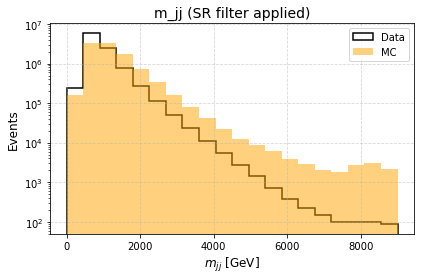

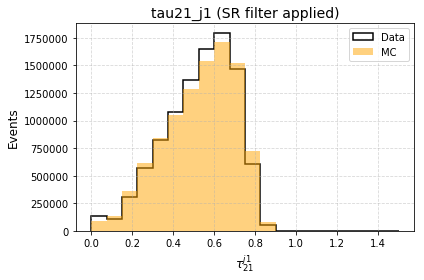

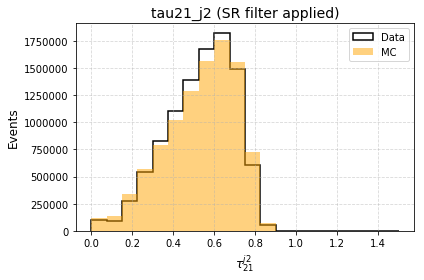

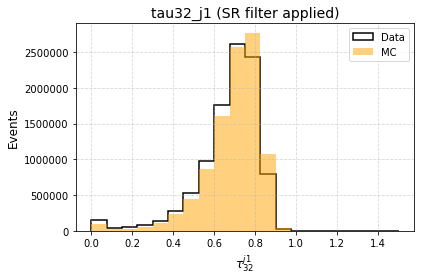

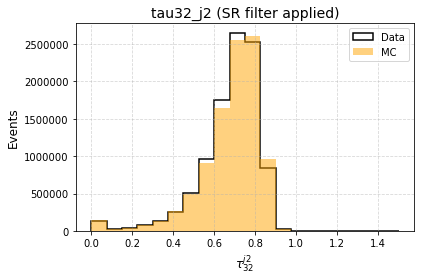

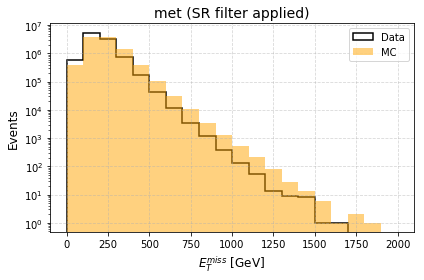

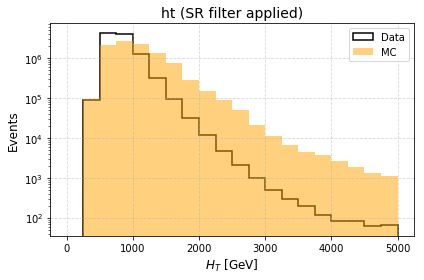

In [16]:
def sr_mask(events):
    ht = events[:,0]  # ht is first column
    met = events[:,1]  # met is second column
    mask = (ht > 600) & (met > 600)
    return mask

mode = "1000_2"
signal_to_plot = signal_samples[mode]

for i, (var, (xmin, xmax, nbins, xlabel, logy)) in enumerate(VARIABLES.items()):
    
    # Filter MC and data
    mc_vals = mc_events[var]
    data_vals = data_events[var]

    mc_vals = mc_vals[np.isfinite(mc_vals)]
    data_vals = data_vals[np.isfinite(data_vals)]

    # Apply SR mask
    mc_mask = sr_mask(np.column_stack([mc_events[v] for v in ["ht", "met"]]))
    data_mask = sr_mask(np.column_stack([data_events[v] for v in ["ht", "met"]]))
    
    # mc_vals = mc_vals[mc_mask]
    # data_vals = data_vals[data_mask]

    # Filter signal
    if var in var_names:
        var_index = var_names.index(var)
        sig_vals = signal_to_plot[:, var_index]
        sig_vals = sig_vals[np.isfinite(sig_vals)]
        
        sig_mask = sr_mask(signal_to_plot[:, [var_names.index("ht"), var_names.index("met")]])
        sig_vals = sig_vals[sig_mask]

    # Plot
    plt.figure(figsize=(6,4))
    plt.hist(data_vals, bins=nbins, range=(xmin, xmax), histtype="step", color="black", label="Data", linewidth=1.5)
    plt.hist(mc_vals, bins=nbins, range=(xmin, xmax), histtype="stepfilled", alpha=0.5, color="orange", label="MC")

    # if var in var_names and len(sig_vals) > 0:
    #     scale_factor = len(data_vals) / len(sig_vals)
    #     plt.hist(sig_vals, bins=nbins, range=(xmin, xmax), histtype="step", color="red", linestyle="--", linewidth=1.5,
    #              label="Signal", weights=np.ones_like(sig_vals) * scale_factor)

    plt.xlabel(xlabel)
    plt.ylabel("Events")
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    if logy:
        plt.yscale("log")
    plt.title(f"{var} (SR filter applied)")
    plt.tight_layout()
    plt.show()
